### Simulating a single electrode for a single participant
- Simulating electrode Cz for a single participant

#### Imports

In [49]:
!pip install --upgrade neurodsp

# Imports required for functionality 
import numpy as np
from matplotlib import pyplot 

from neurodsp.utils import create_times
from neurodsp.sim import sim_oscillation, set_random_seed, sim_combined
from neurodsp.plts import plot_time_series, plot_power_spectra
from neurodsp.spectral import compute_spectrum_welch

from specparam import SpectralModel
from specparam.plts import plot_spectra

#### Data simulation settings

In [20]:
# Set seed for consistency
set_random_seed(256)

# Simulation settings
n_seconds = 8 # Number of seconds
s_rate = 250 # Sampling rate

# Compute an array of time values for plotting, and check length of data
times = create_times(n_seconds, s_rate)

#### Simulate EEG-like signal for electrode Cz

In [36]:
# Cz acts as a reference point for all other electrode signals
components = {'sim_synaptic_current' : {'n_neurons' : 1000, 'firing_rate' : 2,
                                        't_ker' : 1.0, 'tau_r' : 0.002, 'tau_d' : 0.02},
              'sim_bursty_oscillation' : {'freq' : 10}}
component_variances = [1, 0.5]

# Generate combined signal
cz_signal = sim_combined(n_seconds, s_rate, components, component_variances)

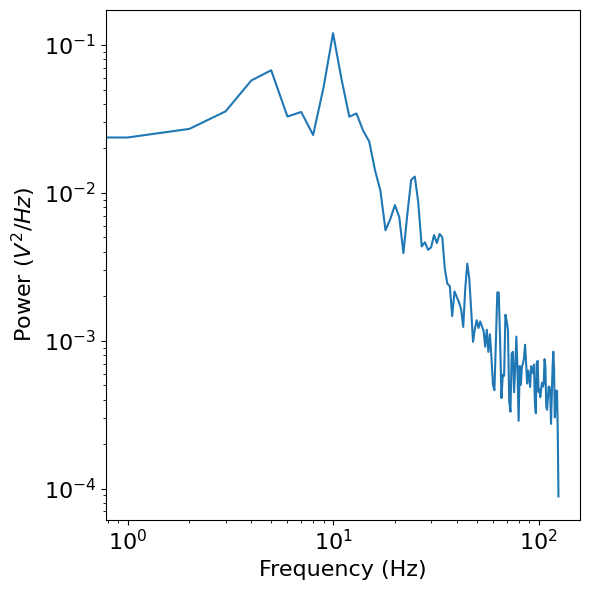

In [34]:
# Plot the simulated data, in the frequency domain
freqs, powers = compute_spectrum_welch(cz_signal, s_rate)
plot_power_spectra(freqs, powers)


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.



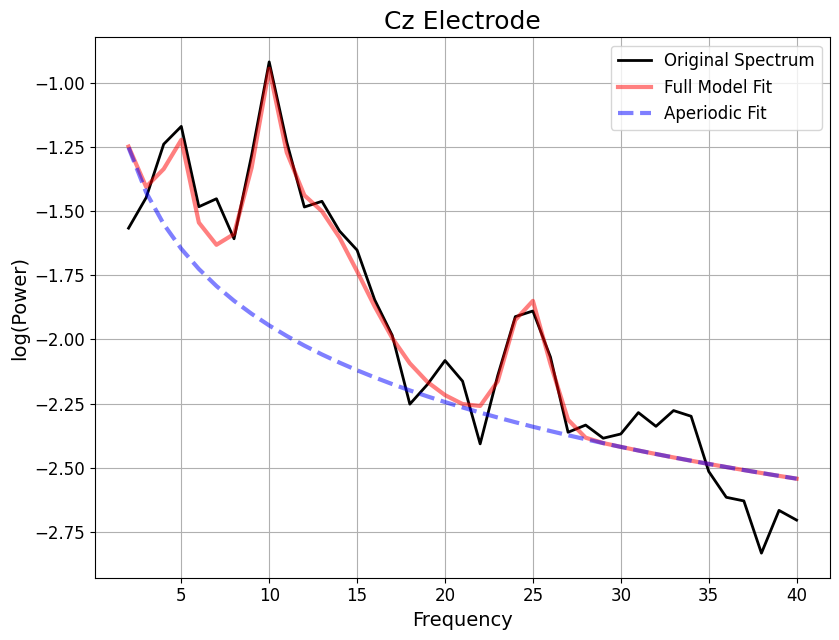

In [35]:
# Initialise Spectral Model
fm_cz = SpectralModel()

# Set frequency range
freq_range = [2, 40]

# Fitting, plotting and reporting spectral models for each signal
fm_cz.fit(freqs, powers, freq_range)
fm_cz.plot(title = "Cz Electrode")